In [1]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
plt.style.use('ggplot')
pd.set_option('display.max_columns', None)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
# Upload Dataset

from google.colab import files

uploaded = files.upload()

Saving country_vaccinations_by_manufacturer.csv to country_vaccinations_by_manufacturer.csv


In [4]:
# Load Dataset

df = pd.read_csv("country_vaccinations_by_manufacturer.csv")

df.head()

,location,date,vaccine,total_vaccinations
0,Argentina,2020-12-29,Moderna,2
1,Argentina,2020-12-29,Oxford/AstraZeneca,3
2,Argentina,2020-12-29,Sinopharm/Beijing,1
3,Argentina,2020-12-29,Sputnik V,20481
4,Argentina,2020-12-30,Moderna,2


In [5]:
# Display basic information about the dataset

print("Shape of Dataset:", df.shape)

print("\nColumn Names:")
print(df.columns)

print("\nDataset Information:")
df.info()

Shape of Dataset: (35623, 4)

Column Names:
Index(['location', 'date', 'vaccine', 'total_vaccinations'], dtype='object')

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35623 entries, 0 to 35622
Data columns (total 4 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   location            35623 non-null  object
 1   date                35623 non-null  object
 2   vaccine             35623 non-null  object
 3   total_vaccinations  35623 non-null  int64 
dtypes: int64(1), object(3)
memory usage: 1.1+ MB


In [6]:
# Display first 10 rows

df.head(10)

,location,date,vaccine,total_vaccinations
0,Argentina,2020-12-29,Moderna,2
1,Argentina,2020-12-29,Oxford/AstraZeneca,3
2,Argentina,2020-12-29,Sinopharm/Beijing,1
3,Argentina,2020-12-29,Sputnik V,20481
4,Argentina,2020-12-30,Moderna,2
5,Argentina,2020-12-30,Oxford/AstraZeneca,3
6,Argentina,2020-12-30,Sinopharm/Beijing,1
7,Argentina,2020-12-30,Sputnik V,40583
8,Argentina,2020-12-31,Moderna,2
9,Argentina,2020-12-31,Oxford/AstraZeneca,3


In [7]:
# Display last 10 rows

df.tail(10)

,location,date,vaccine,total_vaccinations
35613,European Union,2022-03-28,Sputnik V,1845103
35614,European Union,2022-03-29,Covaxin,11
35615,European Union,2022-03-29,Johnson&Johnson,18556428
35616,European Union,2022-03-29,Moderna,145331851
35617,European Union,2022-03-29,Novavax,118968
35618,European Union,2022-03-29,Oxford/AstraZeneca,67403106
35619,European Union,2022-03-29,Pfizer/BioNTech,600519998
35620,European Union,2022-03-29,Sinopharm/Beijing,2301516
35621,European Union,2022-03-29,Sinovac,1809
35622,European Union,2022-03-29,Sputnik V,1845103


In [8]:
# Summary statistics

df.describe(include='all')

,location,date,vaccine,total_vaccinations
count,35623,35623,35623,3.562300e+04
unique,43,473,10,NaN
top,European Union,2021-07-23,Pfizer/BioNTech,NaN
freq,4122,169,8888,NaN
mean,NaN,NaN,NaN,1.508357e+07
std,NaN,NaN,NaN,5.181768e+07
min,NaN,NaN,NaN,0.000000e+00
25%,NaN,NaN,NaN,9.777600e+04
50%,NaN,NaN,NaN,1.305506e+06
75%,NaN,NaN,NaN,7.932423e+06


In [9]:
# Missing values in each column

missing_values = df.isnull().sum()

print(missing_values)

location              0
date                  0
vaccine               0
total_vaccinations    0
dtype: int64


In [10]:
# Percentage of missing values

missing_percent = (df.isnull().sum() / len(df)) * 100

missing_percent.sort_values(ascending=False)

,0
location,0.0
date,0.0
vaccine,0.0
total_vaccinations,0.0


In [11]:
# Remove duplicate rows

df = df.drop_duplicates()

print("Dataset Shape After Removing Duplicates:", df.shape)

Dataset Shape After Removing Duplicates: (35623, 4)


In [12]:
# Convert date column into datetime format

df['date'] = pd.to_datetime(df['date'])

print(df['date'].head())

0   2020-12-29
1   2020-12-29
2   2020-12-29
3   2020-12-29
4   2020-12-30
Name: date, dtype: datetime64[ns]


In [13]:
# Fill missing numerical values using forward fill

df = df.fillna(method='ffill')

print("Remaining Missing Values:")
print(df.isnull().sum())

Remaining Missing Values:
location              0
date                  0
vaccine               0
total_vaccinations    0
dtype: int64


/tmp/ipykernel_1541/3753870786.py:3: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')


In [14]:
# Data types

df.dtypes

,0
location,object
date,datetime64[ns]
vaccine,object
total_vaccinations,int64


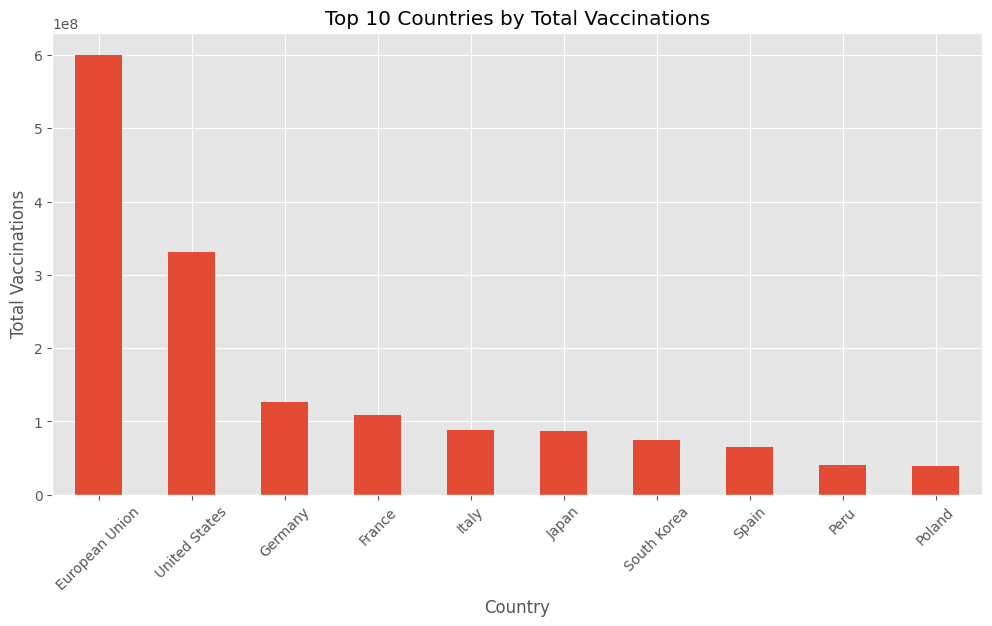

In [17]:
# Top 10 countries by total vaccinations

top10 = (
    df.groupby('location')['total_vaccinations']
      .max()
      .sort_values(ascending=False)
      .head(10)
)

plt.figure(figsize=(12,6))
top10.plot(kind='bar')
plt.title("Top 10 Countries by Total Vaccinations")
plt.xlabel("Country")
plt.ylabel("Total Vaccinations")
plt.xticks(rotation=45)
plt.show()

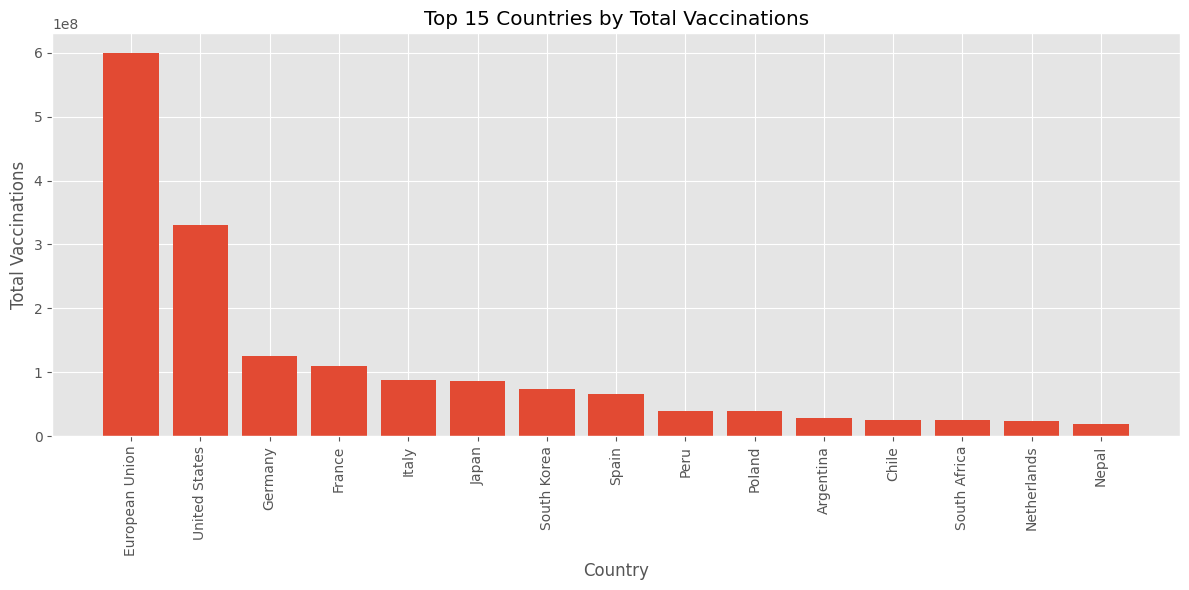

In [18]:
top15 = (
    df.groupby('location')['total_vaccinations']
    .max()
    .sort_values(ascending=False)
    .head(15)
)

plt.figure(figsize=(12,6))
plt.bar(top15.index, top15.values)
plt.xticks(rotation=90)
plt.title("Top 15 Countries by Total Vaccinations")
plt.xlabel("Country")
plt.ylabel("Total Vaccinations")
plt.tight_layout()
plt.show()

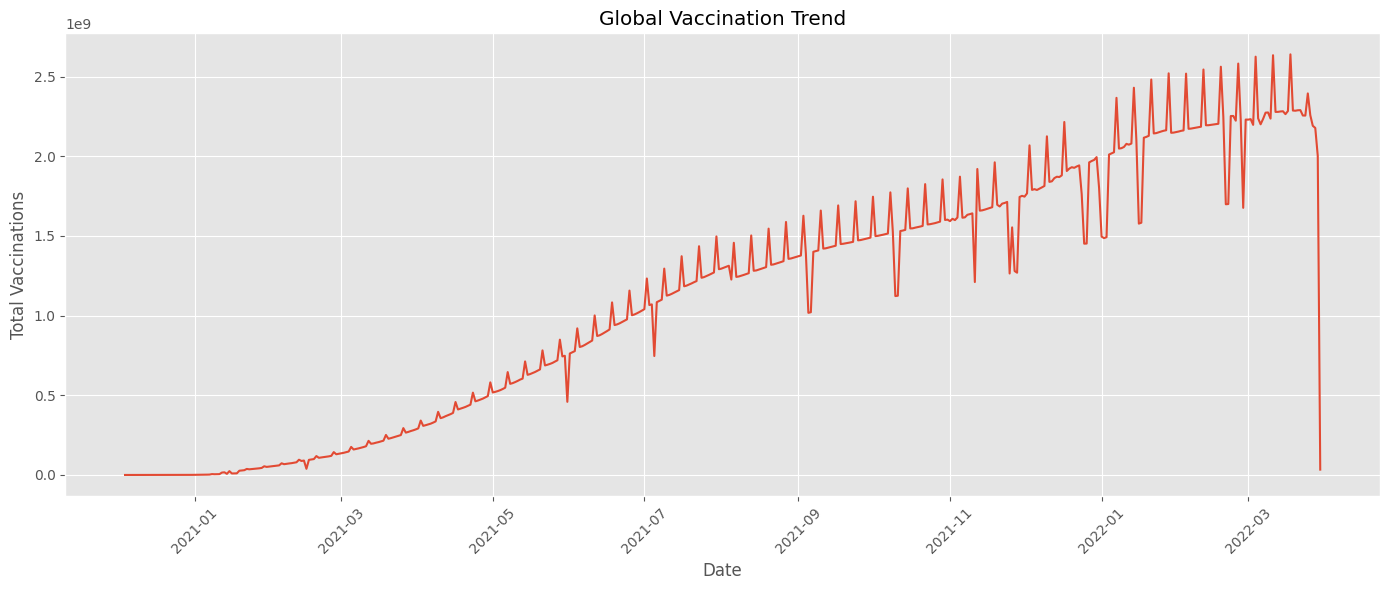

In [19]:
daily = (
    df.groupby('date')['total_vaccinations']
    .sum()
)

plt.figure(figsize=(14,6))
plt.plot(daily.index, daily.values)
plt.title("Global Vaccination Trend")
plt.xlabel("Date")
plt.ylabel("Total Vaccinations")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

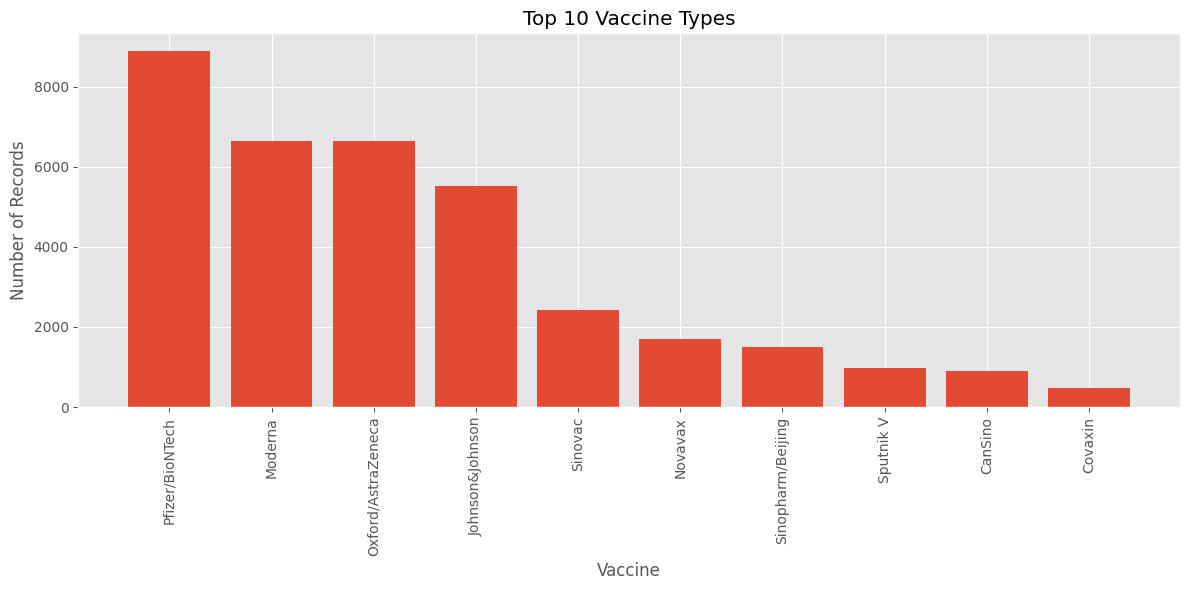

In [20]:
vaccine_count = df['vaccine'].value_counts().head(10)

plt.figure(figsize=(12,6))
plt.bar(vaccine_count.index, vaccine_count.values)
plt.xticks(rotation=90)
plt.title("Top 10 Vaccine Types")
plt.xlabel("Vaccine")
plt.ylabel("Number of Records")
plt.tight_layout()
plt.show()

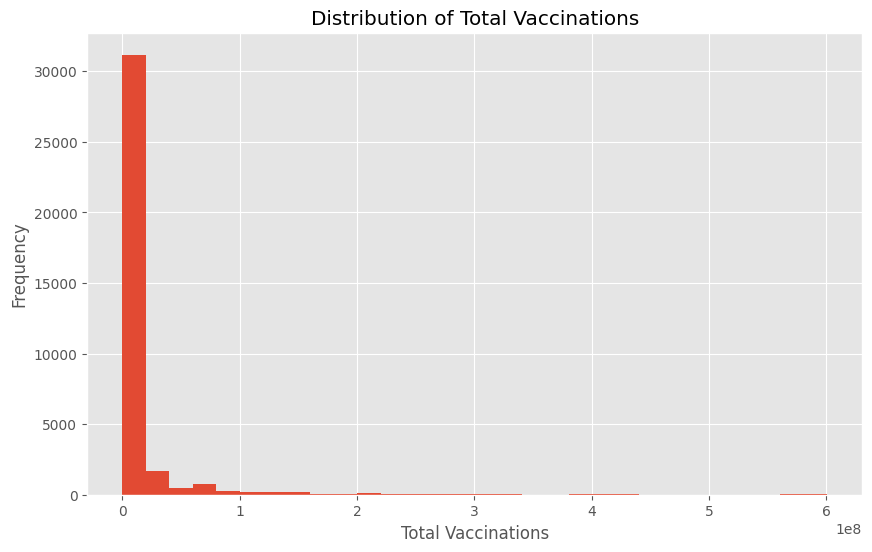

In [21]:
plt.figure(figsize=(10,6))
plt.hist(df['total_vaccinations'].dropna(), bins=30)

plt.title("Distribution of Total Vaccinations")
plt.xlabel("Total Vaccinations")
plt.ylabel("Frequency")

plt.show()

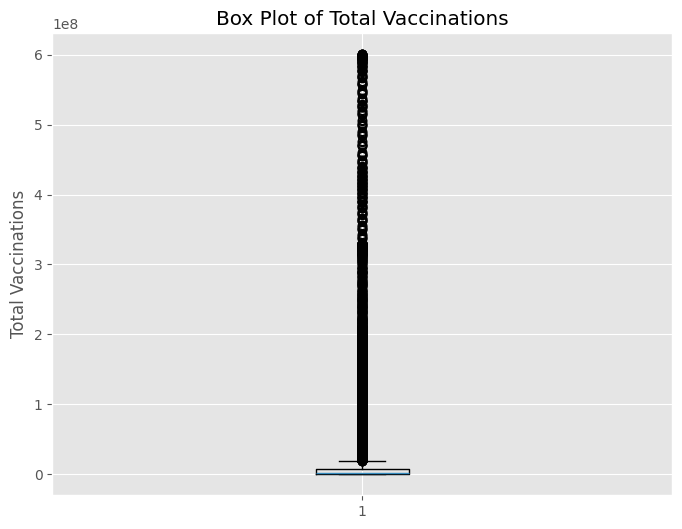

In [22]:
plt.figure(figsize=(8,6))

plt.boxplot(df['total_vaccinations'].dropna())

plt.title("Box Plot of Total Vaccinations")

plt.ylabel("Total Vaccinations")

plt.show()

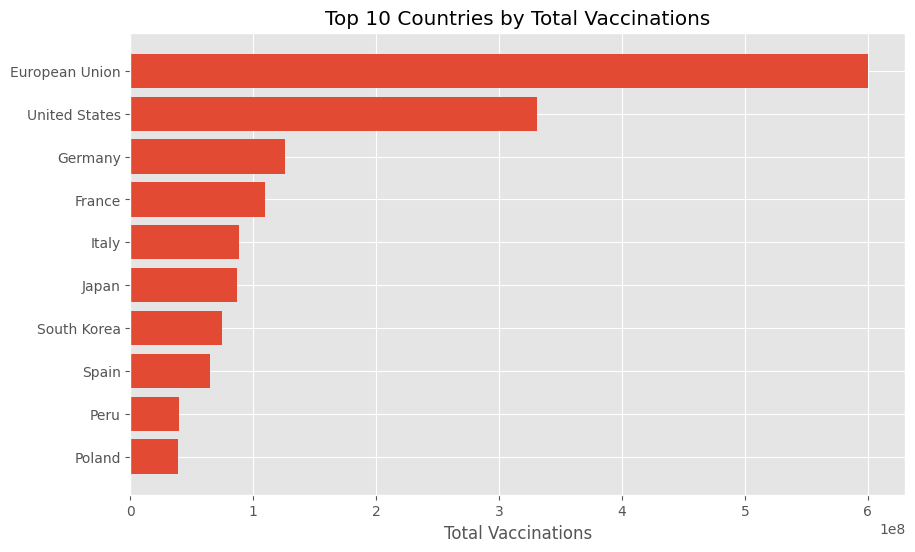

In [23]:
top10 = (
    df.groupby('location')['total_vaccinations']
    .max()
    .sort_values(ascending=True)
    .tail(10)
)

plt.figure(figsize=(10,6))
plt.barh(top10.index, top10.values)

plt.title("Top 10 Countries by Total Vaccinations")

plt.xlabel("Total Vaccinations")

plt.show()

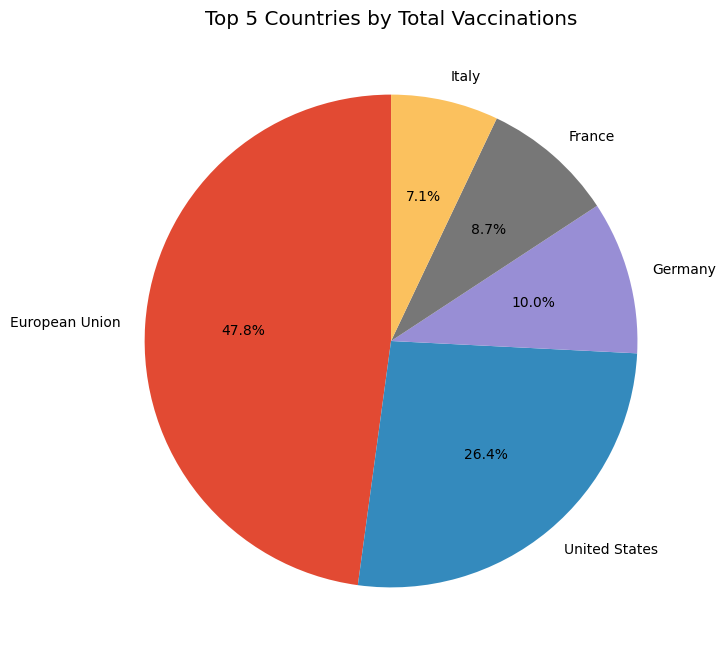

In [24]:
top5 = (
    df.groupby('location')['total_vaccinations']
    .max()
    .sort_values(ascending=False)
    .head(5)
)

plt.figure(figsize=(8,8))

plt.pie(top5.values,
        labels=top5.index,
        autopct='%1.1f%%',
        startangle=90)

plt.title("Top 5 Countries by Total Vaccinations")

plt.show()

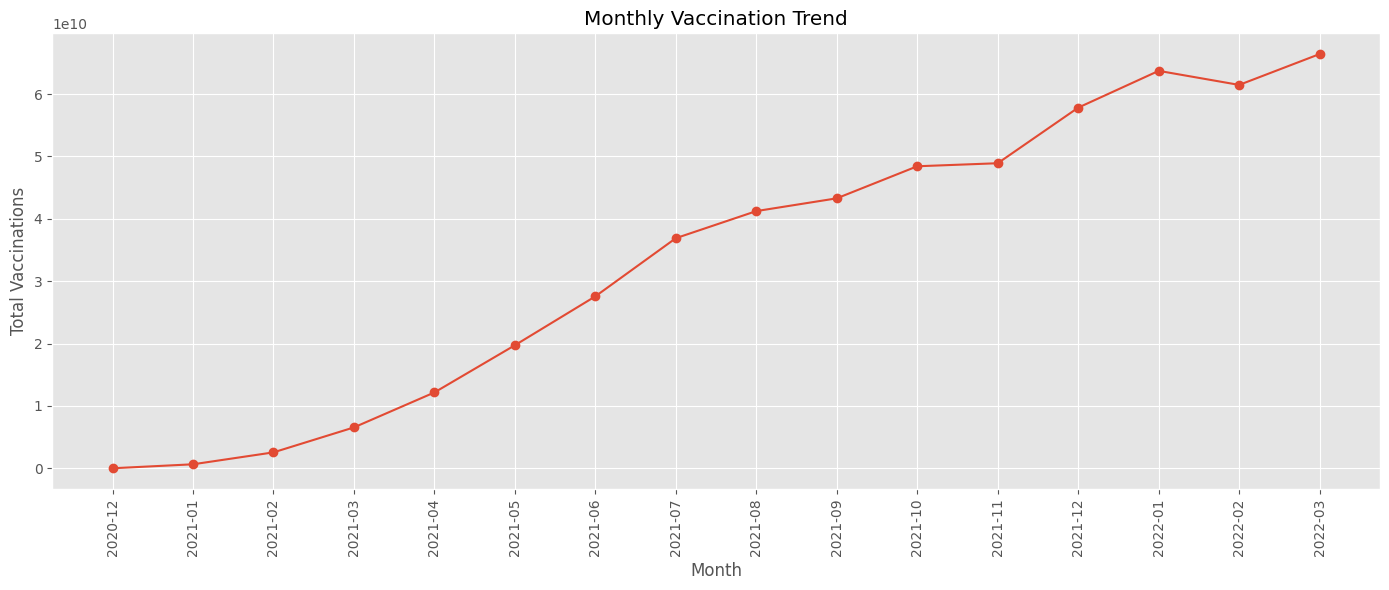

In [25]:
df['month'] = df['date'].dt.to_period('M').astype(str)

monthly = (
    df.groupby('month')['total_vaccinations']
    .sum()
)

plt.figure(figsize=(14,6))

plt.plot(monthly.index, monthly.values, marker='o')

plt.xticks(rotation=90)

plt.title("Monthly Vaccination Trend")

plt.xlabel("Month")

plt.ylabel("Total Vaccinations")

plt.tight_layout()

plt.show()

In [26]:
df.to_csv("vaccination_data_cleaned.csv", index=False)

print("Project Completed Successfully!")

Project Completed Successfully!


# Conclusion

This project analyzed global COVID-19 vaccination data using Python and explored vaccination trends across different countries.

## Key Achievements

- Loaded and cleaned real-world vaccination data.
- Explored the dataset using Pandas.
- Analyzed vaccination trends over time.
- Identified the top countries by total vaccinations.
- Examined vaccine usage patterns.
- Created multiple visualizations using Matplotlib.
- Generated meaningful insights from the data.

## Technologies Used

- Python
- Pandas
- NumPy
- Matplotlib
- Google Colab

## Skills Demonstrated

- Data Cleaning
- Exploratory Data Analysis (EDA)
- Data Visualization
- Statistical Analysis
- Python Programming